### DS675 – Mini Project (Spring 2026)

**Team:** Krishna Vedam, Travis Collins, Saketh Puramsetti  

**Dataset:**  
[Indian Liver Disease Dataset (Kaggle)](https://www.kaggle.com/datasets/paramjeetsinghds/indian-liver-disease-dataset)

---

**Model Type:** Binary Classification  

**Target Variable:**  
Diagnosis *(Liver Disease vs No Liver Disease)*

---

#### 0. Importing Necessary Modules

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Initial Data Inspection

In [15]:
train_df = pd.read_csv("data/Training_indian_liver_disease_dataset.csv")
test_df = pd.read_csv("data/Testing_indian_liver_disease_dataset.csv")

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)
print("\n--- Column names ---")
print(train_df.columns.tolist())
print("\n--- First 5 rows ---")
train_df.head()

Training dataset shape: (68000, 28)
Testing dataset shape: (1500, 28)

--- Column names ---
['Patient_ID', 'Age', 'Gender', 'Occupation', 'BMI', 'Obesity_Class', 'Diet_Quality', 'Physical_Activity', 'Sleep_Hours', 'Smoking_Status', 'Alcohol_Consumption', 'Sym_Fatigue', 'Sym_Jaundice', 'Sym_Abdominal_Pain', 'Sym_Itching', 'Sym_Ascites', 'Sym_Dark_Urine', 'Sym_Weight_Loss', 'Comorb_Diabetes', 'Comorb_Hypertension', 'Comorb_Genetic_History', 'ALT', 'AST', 'Bilirubin', 'Albumin', 'Platelets', 'Alk_Phosphatase', 'Liver_Disease_Type']

--- First 5 rows ---


,Patient_ID,Age,Gender,Occupation,BMI,Obesity_Class,Diet_Quality,Physical_Activity,Sleep_Hours,Smoking_Status,...,Comorb_Diabetes,Comorb_Hypertension,Comorb_Genetic_History,ALT,AST,Bilirubin,Albumin,Platelets,Alk_Phosphatase,Liver_Disease_Type
0,P23743,49,Male,Healthcare Worker,21.0,Normal,Average,Moderate,4.9,Never,...,0,0,0,25.58,29.30,1.26,4.74,334,119,Fatty_Liver
1,P59795,49,Male,Business,22.6,Normal,Healthy,Low,8.2,Current,...,0,1,0,22.98,30.41,0.73,3.67,224,89,Normal
2,P17597,66,Male,Healthcare Worker,19.5,Normal,Poor,Low,5.1,Never,...,0,0,0,65.46,45.63,0.70,4.27,304,109,Fatty_Liver
3,P27987,75,Female,Office Worker,21.5,Normal,Average,Moderate,6.2,Former,...,0,0,0,55.88,74.40,0.98,4.12,367,102,Alcoholic_Liver_Disease
4,P45429,51,Female,Housewife,22.8,Normal,Poor,Low,7.8,Never,...,1,1,0,72.63,49.17,2.79,4.12,49,114,Cirrhosis


In [16]:
print("--- Data types ---")
print(train_df.dtypes)

print("\n--- Null counts ---")
print(train_df.isnull().sum())

print("\n--- Target distribution ---")
print(train_df['Liver_Disease_Type'].value_counts())

--- Data types ---
Patient_ID                 object
Age                         int64
Gender                     object
Occupation                 object
BMI                       float64
Obesity_Class              object
Diet_Quality               object
Physical_Activity          object
Sleep_Hours               float64
Smoking_Status             object
Alcohol_Consumption        object
Sym_Fatigue                 int64
Sym_Jaundice                int64
Sym_Abdominal_Pain          int64
Sym_Itching                 int64
Sym_Ascites                 int64
Sym_Dark_Urine              int64
Sym_Weight_Loss             int64
Comorb_Diabetes             int64
Comorb_Hypertension         int64
Comorb_Genetic_History      int64
ALT                       float64
AST                       float64
Bilirubin                 float64
Albumin                   float64
Platelets                   int64
Alk_Phosphatase             int64
Liver_Disease_Type         object
dtype: object

--- Null count

#### Observations

1. Alcohol_Consumption has 30,623 null values, which is about 45% of the training data. That’s too much missing data to handle reliably, so this column will be dropped.

2. There are no missing values in the other columns, so no additional imputation is needed.

#### 2. Data Preprocessing and Preparation

In [17]:
# Dropping Patient_ID (identifier, no signal) and Alcohol_Consumption (45% missing)
train_df.drop(columns=['Patient_ID', 'Alcohol_Consumption'], inplace=True)
test_df.drop(columns=['Patient_ID', 'Alcohol_Consumption'], inplace=True)

# Creating a new binary target varible: 0 = Normal, 1 = Liver Disease
train_df['target'] = (train_df['Liver_Disease_Type'] != 'Normal').astype(int)
test_df['target'] = (test_df['Liver_Disease_Type'] != 'Normal').astype(int)

# Dropping original target column
train_df.drop(columns=['Liver_Disease_Type'], inplace=True)
test_df.drop(columns=['Liver_Disease_Type'], inplace=True)

print("Train shape after cleanup:", train_df.shape)
print("\nBinary target distribution:")
print(train_df['target'].value_counts())
print("\nClass ratio:", round(train_df['target'].value_counts()[1] / train_df['target'].value_counts()[0], 2))

Train shape after cleanup: (68000, 26)

Binary target distribution:
target
1    51000
0    17000
Name: count, dtype: int64

Class ratio: 3.0


#### Observations:

The dataset is moderately imbalanced (≈3:1). To mitigate potential bias toward the majority class, SMOTE will be applied during model training.

#### 3. Exploratory Data Analysis

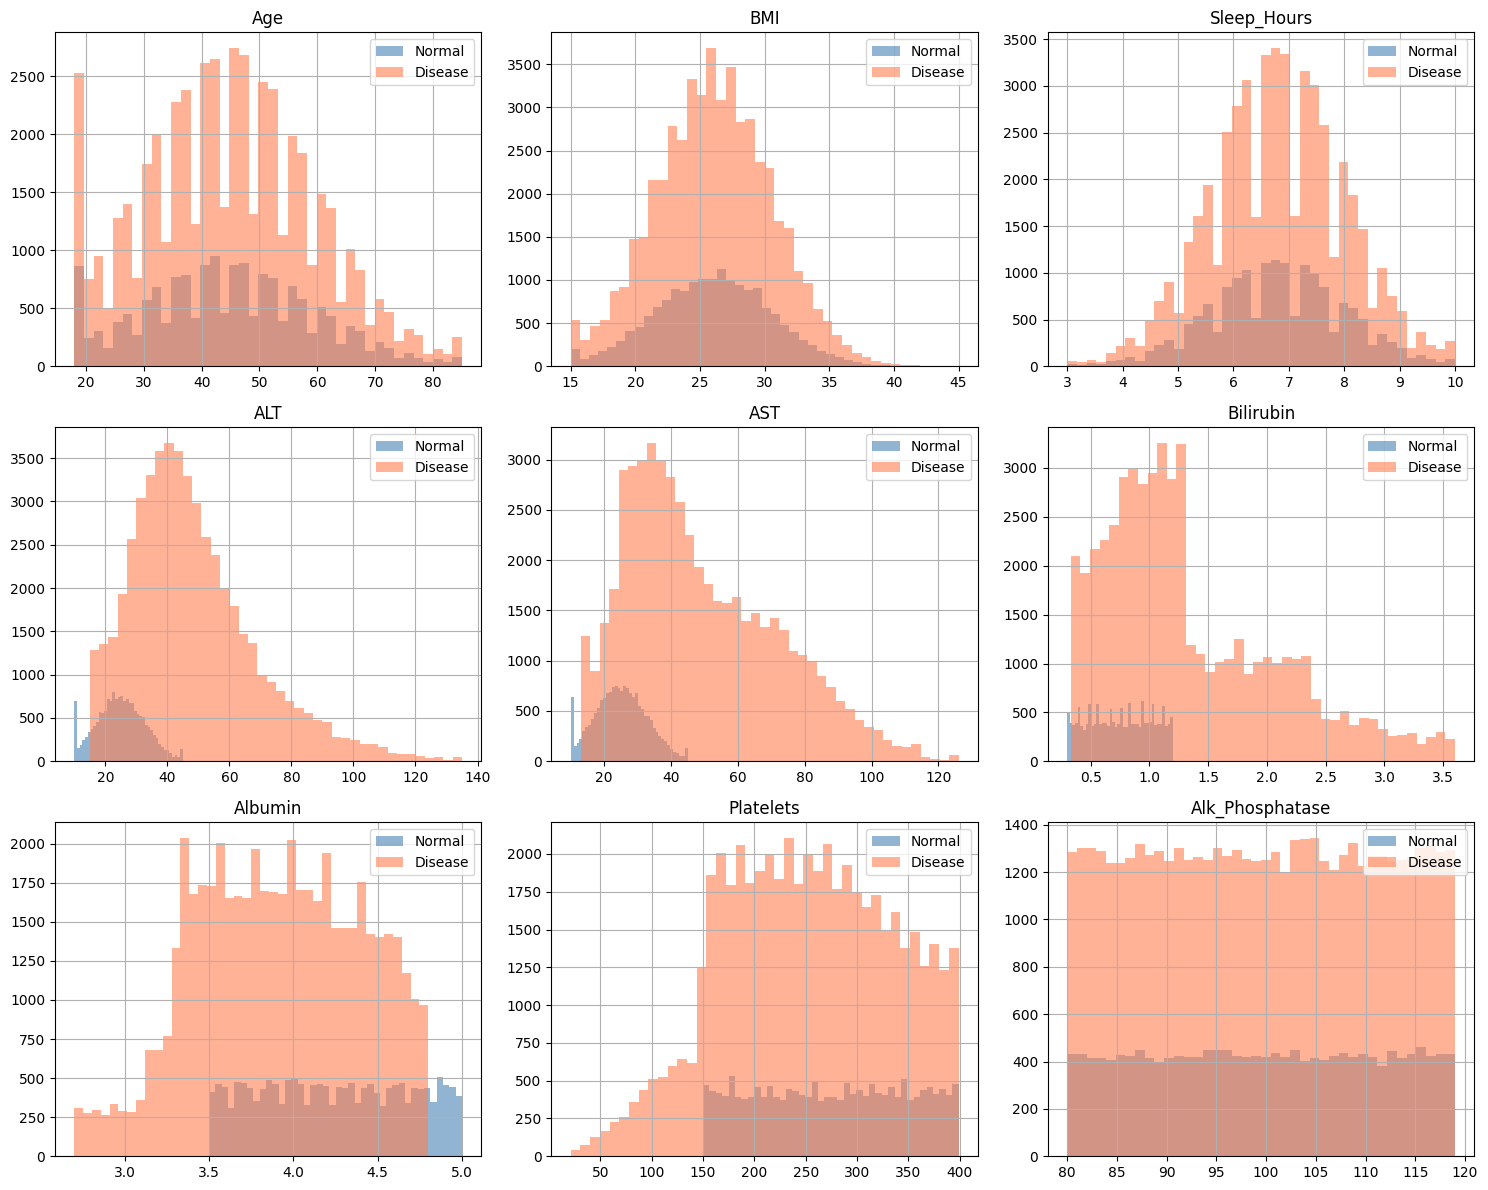

In [18]:
# Numerical features only
num_cols = ['Age', 'BMI', 'Sleep_Hours', 'ALT', 'AST', 
            'Bilirubin', 'Albumin', 'Platelets', 'Alk_Phosphatase']

# Distribution of numerical features by target
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(num_cols):
    ax = axes[i//3][i%3]
    train_df[train_df['target']==0][col].hist(ax=ax, alpha=0.6, label='Normal', bins=40, color='steelblue')
    train_df[train_df['target']==1][col].hist(ax=ax, alpha=0.6, label='Disease', bins=40, color='coral')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

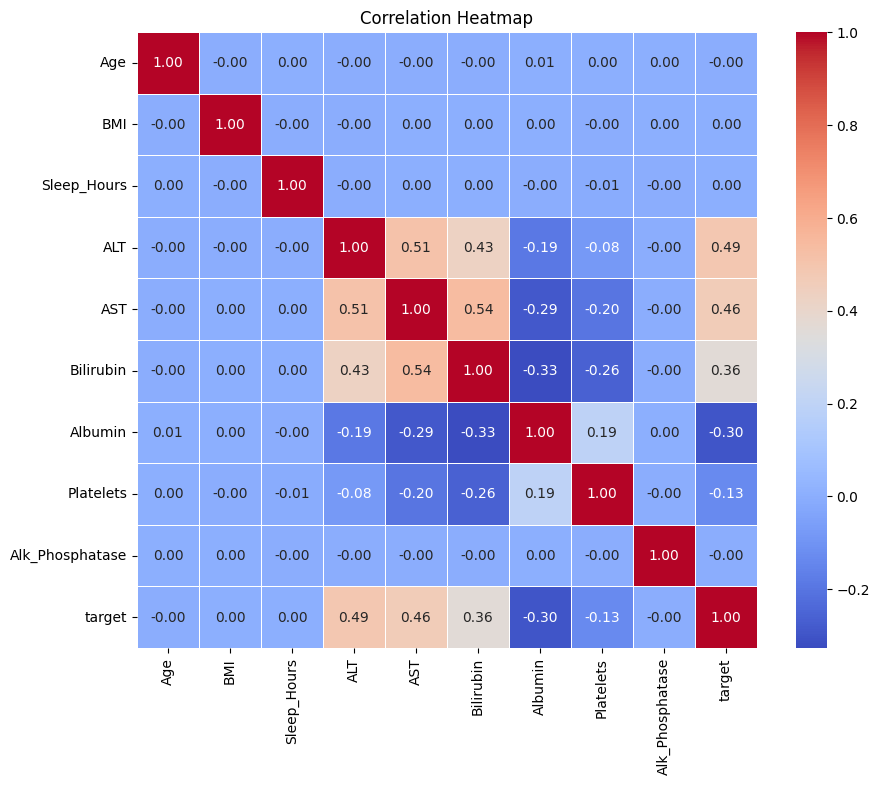

In [19]:
# Correlation heatmap on numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[num_cols + ['target']].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

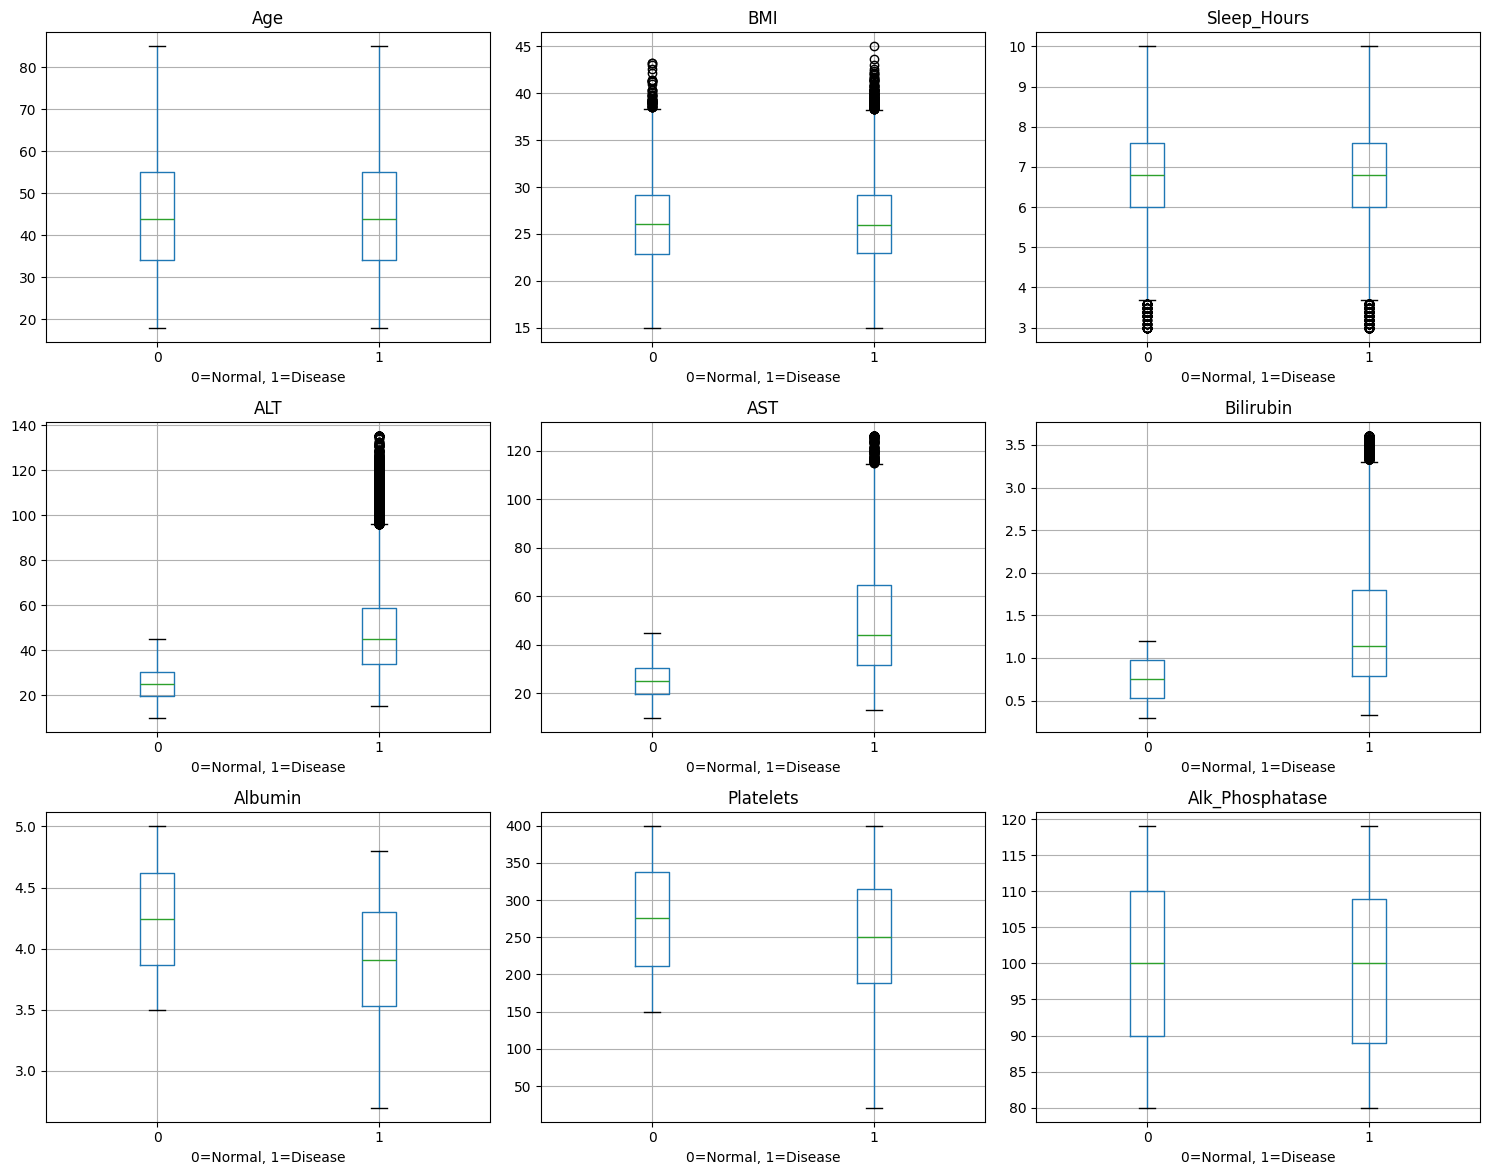

In [20]:
# Boxplots — spot outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(num_cols):
    ax = axes[i//3][i%3]
    train_df.boxplot(column=col, by='target', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('0=Normal, 1=Disease')
plt.suptitle('')
plt.tight_layout()
plt.show()

#### Observations:

**Histograms:**
1. ALT, AST, Bilirubin — disease patients shift right (they have higher values). Normal patients are towards the left while the disease values are towards the right this is a strong signal.
2. Albumin - it follows an opposite trend, normal patients shift right with higher values and disease patients are slightly towards the left. This indicates a negative signal
3. Platelets - disease patients tend to have lower values, indicates a slight negative signal

**Heatmap:**

1. Looking at the heat map only 5 features have a correlation with the target
2. Corelations with target: ALT(0.49), AST(0.46), Bilirubin(0.36), Albumin(-0.30) and Platelets(-0.13)

**Boxplots:**

1. ALT, AST and Bilirubin have outliers in the disease class.
2. Alk_Phosphatase plots are both identical, this feature can be dropped

#### 4. Feature Selection and Outlier Capping

In [24]:
num_features = ['ALT', 'AST', 'Bilirubin', 'Albumin', 'Platelets']

X_train = train_df[num_features].copy()
y_train = train_df['target'].copy()

X_test = test_df[num_features].copy()
y_test = test_df['target'].copy()

# Cap outliers at 1st and 99th percentile (Winsorization)
# We fit the caps on train only, then apply to test
from scipy.stats import mstats

for col in num_features:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper) 

print("Outlier capping done.")
print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Verify outliers are reduced
print("\nALT max before/after (train):", train_df['ALT'].max(), "->", X_train['ALT'].max())
print("AST max before/after (train):", train_df['AST'].max(), "->", X_train['AST'].max())
print("Bilirubin max before/after (train):", train_df['Bilirubin'].max(), "->", X_train['Bilirubin'].max())


Outlier capping done.

X_train shape: (68000, 5)
X_test shape: (1500, 5)

ALT max before/after (train): 135.0 -> 107.3101999999999
AST max before/after (train): 126.0 -> 104.8401999999999
Bilirubin max before/after (train): 3.6 -> 3.39
